# DSCI FINAL
## 組員
- 111590004
- 111590011
- 111590028
- 111590042

## 功能

主要是用來做分析用

# 載入資料

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
import platform

plt.rcParams['axes.unicode_minus'] = False
if platform.system() == "Windows":
    plt.rcParams['font.family'] = 'Microsoft JhengHei'
elif platform.system() == "Darwin":
    plt.rcParams['font.family'] = 'PingFang HK'
else:
    plt.rcParams['font.family'] = 'Noto Sans CJK TC'
plt.rcParams["axes.unicode_minus"] = False

# 讀取資料
bachelor_df = pd.read_csv("data/after_clean/大學資料_學士.csv", encoding="utf-8-sig")
master_df = pd.read_csv("data/after_clean/大學資料_碩士.csv", encoding="utf-8-sig")

salary_bachelor_df = pd.read_csv("data/after_clean/薪資統計_學士.csv", encoding="utf-8-sig")
salary_master_df = pd.read_csv("data/after_clean/薪資統計_碩士.csv", encoding="utf-8-sig")

lookup_df = pd.read_csv("data/before_clean/學門查詢.csv", encoding="utf-8-sig")

/var/folders/79/cfth2x2j34qd4mkm_1q9c6cw0000gn/T/ipykernel_67369/2496669518.py:4: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.3.3)
  from scipy.stats import pearsonr, spearmanr


In [2]:
# === 從工程學門拆出「電機與電子工程細學類」(細學類代碼 07141) ===
# 工程及工程業學門底下含電機電子，這裡把 07141 細學類拉出來，當成與「學門」並列的分析單位，
# 後面所有以「學門」為單位的統計與圖（散點、相關、排名、藍海、雙漲、逐年趨勢）都會一起涵蓋它。
# 註：07141 與「工程及工程業學門」有重疊（前者是後者的子集），散點圖會同時出現兩個點，屬預期行為。
EE_FIELD = "電機與電子工程細學類"

# 薪資：讀入已清理的 07141 細學類薪資，欄名「細學類」對齊成「學門」後，併入學士／碩士薪資表
_ee_salary = (
    pd.read_csv("data/after_clean/薪資統計_電機電子細學類.csv", encoding="utf-8-sig")
    .rename(columns={"細學類": "學門"})[["統計期", "畢業年", "學位", "學門", "薪資"]]
)

salary_bachelor_df = pd.concat(
    [salary_bachelor_df, _ee_salary[_ee_salary["學位"] == "學士"]],
    ignore_index=True
)
salary_master_df = pd.concat(
    [salary_master_df, _ee_salary[_ee_salary["學位"] == "碩士"]],
    ignore_index=True
)

# 整理學門資料表

將不重要的學門資料排除

In [3]:
lookup_clean = lookup_df.copy()

for col, prefix in [
    ("領域代碼/名稱", "領域"),
    ("學門代碼/名稱", "學門"),
    ("學類代碼/名稱", "學類"),
    ("細學類代碼/名稱", "細學類"),
]:
    lookup_clean[f"{prefix}代碼"] = (
        lookup_clean[col]
        .astype(str)
        .str.extract(r"^(\d+)")[0]
    )

    lookup_clean[f"{prefix}名稱"] = (
        lookup_clean[col]
        .astype(str)
        .str.replace(r"^\d+\s*", "", regex=True)
    )

lookup_clean = lookup_clean[
    [
        "領域代碼", "領域名稱",
        "學門代碼", "學門名稱",
        "學類代碼", "學類名稱",
        "細學類代碼", "細學類名稱"
    ]
].drop_duplicates()

lookup_clean.head()

,領域代碼,領域名稱,學門代碼,學門名稱,學類代碼,學類名稱,細學類代碼,細學類名稱
0,01,教育領域,011,教育學門,0111,教育學學類,01111,綜合教育細學類
1,01,教育領域,011,教育學門,0111,教育學學類,01112,成人教育細學類
2,01,教育領域,011,教育學門,0111,教育學學類,01113,特殊教育細學類
3,01,教育領域,011,教育學門,0111,教育學學類,01114,教育行政細學類
4,01,教育領域,011,教育學門,0111,教育學學類,01115,課程與教學細學類


# 用科系代碼前五碼對應學門

讀取大學資料
將科系代碼過濾，比如 01111001 修正成 01111
讓資料可以與學門查詢的細學類代碼對應

In [4]:
def normalize_department_code(code):
    if pd.isna(code):
        return np.nan

    code = str(code).strip()

    if code.endswith(".0"):
        code = code[:-2]

    code = code.replace(" ", "")

    # 如果是純數字，且長度不足 8 碼，補回前導 0
    if code.isdigit() and len(code) < 8:
        code = code.zfill(8)

    return code

def prepare_university_data(df, degree_name):
    df = df.copy()

    df["學生數"] = pd.to_numeric(
        df["學生數"].astype(str).str.replace(",", "", regex=False),
        errors="coerce"
    )

    df["科系代碼_字串"] = df["科系代碼"].apply(normalize_department_code)

    # 科系代碼前五碼 = 細學類代碼
    df["細學類代碼"] = df["科系代碼_字串"].str[:5]

    df = df.merge(
        lookup_clean,
        on="細學類代碼",
        how="left"
    )

    df["學位"] = degree_name

    return df

bachelor_clean = prepare_university_data(bachelor_df, "學士")
master_clean = prepare_university_data(master_df, "碩士")

university_df = pd.concat(
    [bachelor_clean, master_clean],
    ignore_index=True
)

university_df.head()

,學校代碼,學校名稱,科系代碼,科系名稱,日間∕進修別,等級別,學生數,年份,科系代碼_字串,細學類代碼,領域代碼,領域名稱,學門代碼,學門名稱,學類代碼,學類名稱,細學類名稱,學位
0,1,國立政治大學,1111001,教育學系,D 日,B 學士,225.0,109,01111001,01111,01,教育領域,011,教育學門,0111,教育學學類,綜合教育細學類,學士
1,1,國立政治大學,2221020,歷史學系,D 日,B 學士,160.0,109,02221020,02221,02,藝術及人文領域,022,人文學門,0222,歷史及考古學學類,歷史細學類,學士
2,1,國立政治大學,2222031,民族學系,D 日,B 學士,178.0,109,02222031,02222,02,藝術及人文領域,022,人文學門,0222,歷史及考古學學類,人類學及民族學細學類,學士
3,1,國立政治大學,2231022,哲學系,D 日,B 學士,179.0,109,02231022,02231,02,藝術及人文領域,022,人文學門,0223,哲學學類,哲學細學類,學士
4,1,國立政治大學,2311009,英國語文學系,D 日,B 學士,292.0,109,02311009,02311,02,藝術及人文領域,023,語文學門,0231,外國語文學學類,外國語文細學類,學士


In [5]:
missing_lookup = university_df[university_df["學門名稱"].isna()]

print("無法對應學門的資料筆數：", len(missing_lookup))

missing_lookup[
    ["學位", "年份", "學校名稱", "科系代碼", "科系代碼_字串", "細學類代碼", "科系名稱"]
].drop_duplicates().head(30)

無法對應學門的資料筆數： 0


,學位,年份,學校名稱,科系代碼,科系代碼_字串,細學類代碼,科系名稱


# 統計 109～113 年各學門就讀人數

區分學士碩士

In [6]:
enroll_yearly = (
    university_df[
        university_df["學門名稱"].notna()
        & university_df["年份"].between(109, 113)
    ]
    .groupby(["學位", "年份", "學門名稱"], as_index=False)["學生數"]
    .sum()
    .rename(columns={"學門名稱": "學門"})
)

enroll_yearly.head()

,學位,年份,學門,學生數
0,學士,109,人文學門,9710.0
1,學士,109,其他學門,969.0
2,學士,109,商業及管理學門,82229.0
3,學士,109,安全服務學門,364.0
4,學士,109,工程及工程業學門,60067.0


In [7]:
# 07141 電機與電子工程細學類 的逐年就讀人數（以科系代碼前五碼 == 07141 篩選）
# 直接以代碼為主，07141 底下少數「資訊工程」系所也一併計入（約占 5%）。
_ee_enroll = (
    university_df[
        (university_df["細學類代碼"] == "07141")
        & university_df["年份"].between(109, 113)
    ]
    .groupby(["學位", "年份"], as_index=False)["學生數"]
    .sum()
)
_ee_enroll["學門"] = EE_FIELD

enroll_yearly = pd.concat([enroll_yearly, _ee_enroll], ignore_index=True)

enroll_yearly[enroll_yearly["學門"] == EE_FIELD]

,學位,年份,學門,學生數
270,學士,109,電機與電子工程細學類,25414.0
271,學士,110,電機與電子工程細學類,25886.0
272,學士,111,電機與電子工程細學類,25923.0
273,學士,112,電機與電子工程細學類,26886.0
274,學士,113,電機與電子工程細學類,27157.0
275,碩士,109,電機與電子工程細學類,15579.0
276,碩士,110,電機與電子工程細學類,16269.0
277,碩士,111,電機與電子工程細學類,17160.0
278,碩士,112,電機與電子工程細學類,17897.0
279,碩士,113,電機與電子工程細學類,19757.0


# 人數近五年統計

In [8]:
enroll_summary = (
    enroll_yearly
    .groupby(["學位", "學門"], as_index=False)
    .agg(
        五年總就讀人數=("學生數", "sum"),
        五年平均就讀人數=("學生數", "mean"),
        人數年度數=("年份", "nunique")
    )
)

enroll_summary.head()

,學位,學門,五年總就讀人數,五年平均就讀人數,人數年度數
0,學士,人文學門,46438.0,9287.6,5
1,學士,其他學門,6476.0,1295.2,5
2,學士,商業及管理學門,389941.0,77988.2,5
3,學士,安全服務學門,1389.0,277.8,5
4,學士,工程及工程業學門,306015.0,61203.0,5


# 整理 109～113 畢業薪資

In [9]:
def prepare_salary_data(df):
    df = df.copy()

    df["薪資"] = pd.to_numeric(df["薪資"], errors="coerce")

    df["畢業年份"] = (
        df["畢業年"]
        .astype(str)
        .str.extract(r"(\d+)")[0]
        .astype(int)
    )

    df["統計期_year"] = (
        df["統計期"]
        .astype(str)
        .str.extract(r"(\d+)年")[0]
        .astype(int)
    )

    df["統計期_month"] = (
        df["統計期"]
        .astype(str)
        .str.extract(r"年\s*(\d+)月")[0]
        .astype(int)
    )

    df = df[df["畢業年份"].between(109, 113)]

    latest_salary = (
        df.sort_values(["統計期_year", "統計期_month"])
        .groupby(["學位", "學門", "畢業年份"], as_index=False)
        .tail(1)
    )

    salary_summary = (
        latest_salary
        .groupby(["學位", "學門"], as_index=False)
        .agg(
            五年平均薪資=("薪資", "mean"),
            最高薪資=("薪資", "max"),
            最低薪資=("薪資", "min"),
            薪資畢業年數=("畢業年份", "nunique")
        )
    )

    return salary_summary

# 合併人數薪資

In [10]:
salary_summary = pd.concat(
    [
        prepare_salary_data(salary_bachelor_df),
        prepare_salary_data(salary_master_df)
    ],
    ignore_index=True
)

salary_summary.head()

,學位,學門,五年平均薪資,最高薪資,最低薪資,薪資畢業年數
0,學士,人文學門,38217.2,40421.0,35793.0,5
1,學士,其他學門,46909.2,57818.0,40446.0,5
2,學士,商業及管理學門,40304.2,42753.0,37392.0,5
3,學士,安全服務學門,38199.8,41208.0,35528.0,5
4,學士,工程及工程業學門,44809.0,48270.0,40264.0,5


In [11]:
analysis_df = enroll_summary.merge(
    salary_summary,
    on=["學位", "學門"],
    how="inner"
)

analysis_df.head()

,學位,學門,五年總就讀人數,五年平均就讀人數,人數年度數,五年平均薪資,最高薪資,最低薪資,薪資畢業年數
0,學士,人文學門,46438.0,9287.6,5,38217.2,40421.0,35793.0,5
1,學士,其他學門,6476.0,1295.2,5,46909.2,57818.0,40446.0,5
2,學士,商業及管理學門,389941.0,77988.2,5,40304.2,42753.0,37392.0,5
3,學士,安全服務學門,1389.0,277.8,5,38199.8,41208.0,35528.0,5
4,學士,工程及工程業學門,306015.0,61203.0,5,44809.0,48270.0,40264.0,5


# 算相關係數

In [12]:
def correlation_report(df, degree):
    target = df[
        df["學位"].eq(degree)
    ].dropna(subset=["五年平均就讀人數", "五年平均薪資"])

    pearson_result = pearsonr(
        target["五年平均就讀人數"],
        target["五年平均薪資"]
    )

    spearman_result = spearmanr(
        target["五年平均就讀人數"],
        target["五年平均薪資"]
    )

    print(f"===== {degree} =====")
    print(f"樣本數：{len(target)} 個學門")
    print(f"Pearson correlation：  {pearson_result.statistic:.3f}")
    print(f"Pearson p-value：      {pearson_result.pvalue:.4f}")
    print(f"Spearman correlation： {spearman_result.statistic:.3f}")
    print(f"Spearman p-value：     {spearman_result.pvalue:.4f}")

correlation_report(analysis_df, "學士")
correlation_report(analysis_df, "碩士")

===== 學士 =====
樣本數：28 個學門
Pearson correlation：  0.234
Pearson p-value：      0.2307
Spearman correlation： 0.224
Spearman p-value：     0.2509
===== 碩士 =====
樣本數：27 個學門
Pearson correlation：  0.595
Pearson p-value：      0.0011
Spearman correlation： 0.413
Spearman p-value：     0.0324


# 畫圖

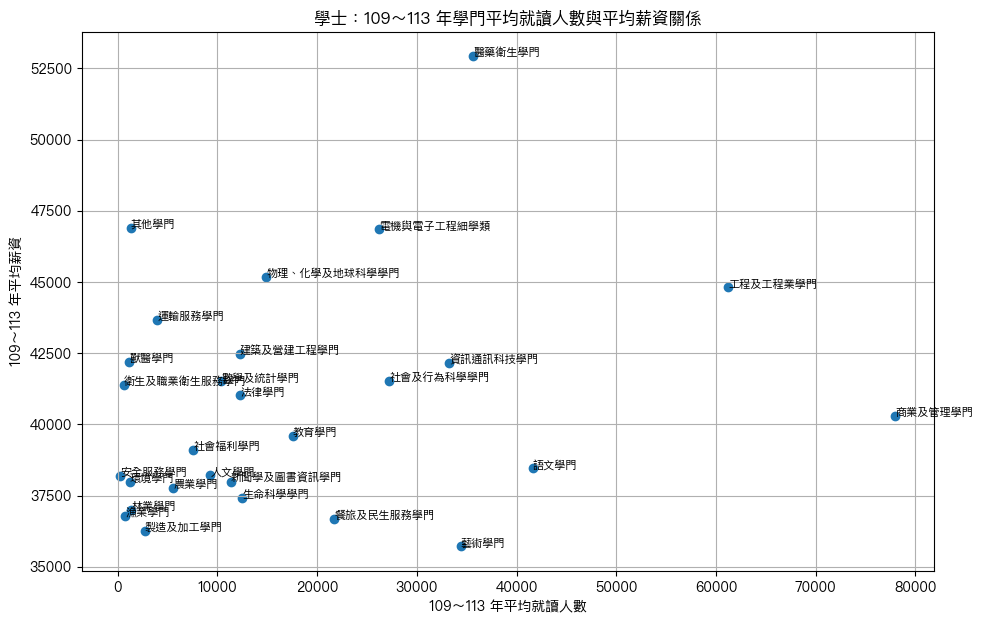

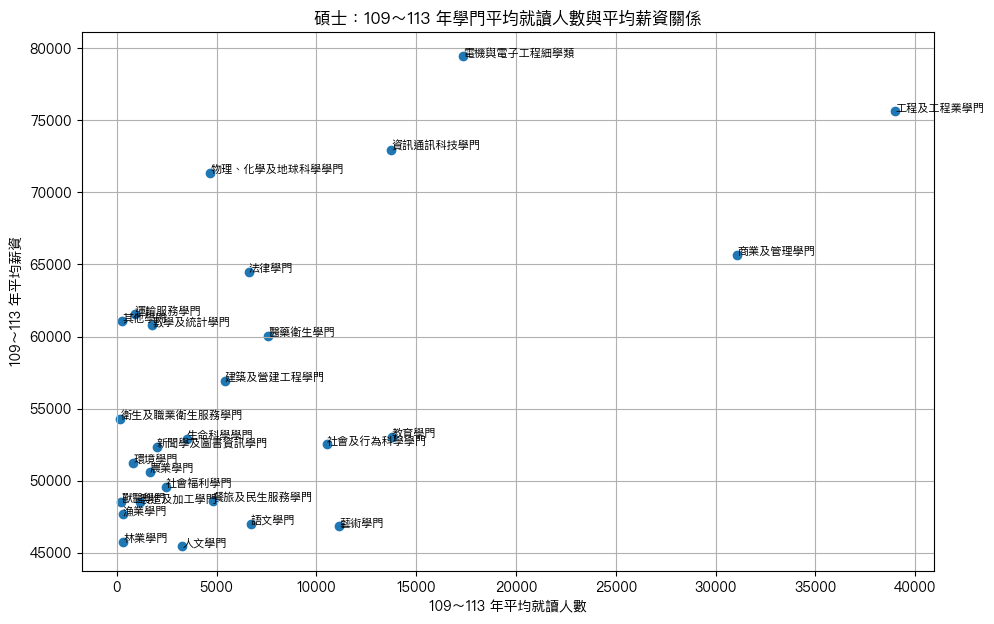

In [13]:
def plot_scatter(df, degree):
    target = df[df["學位"] == degree].copy()

    plt.figure(figsize=(11, 7))
    plt.scatter(
        target["五年平均就讀人數"],
        target["五年平均薪資"]
    )

    for _, row in target.iterrows():
        plt.text(
            row["五年平均就讀人數"],
            row["五年平均薪資"],
            row["學門"],
            fontsize=8
        )

    plt.title(f"{degree}：109～113 年學門平均就讀人數與平均薪資關係")
    plt.xlabel("109～113 年平均就讀人數")
    plt.ylabel("109～113 年平均薪資")
    plt.grid(True)
    plt.show()

plot_scatter(analysis_df, "學士")
plot_scatter(analysis_df, "碩士")

# 薪資前十名的圖

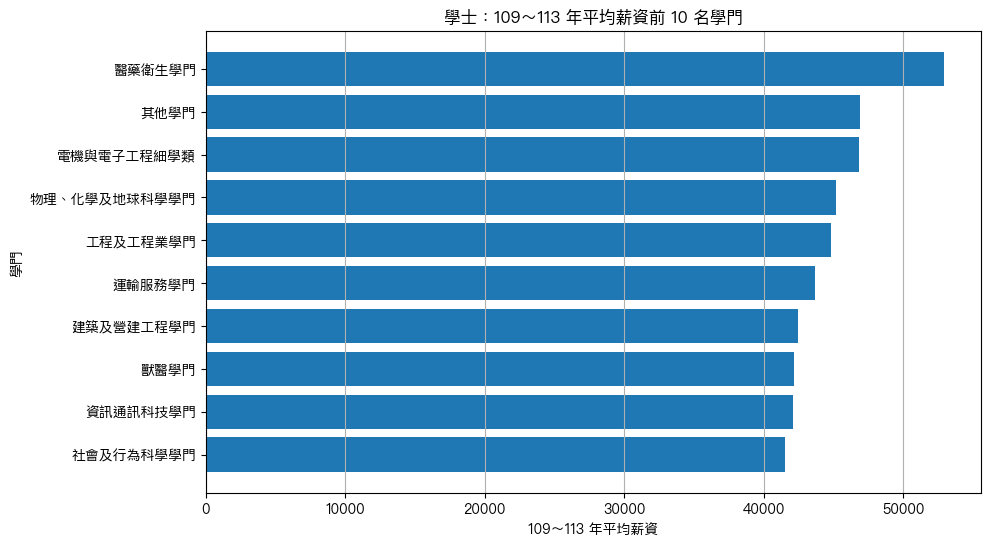

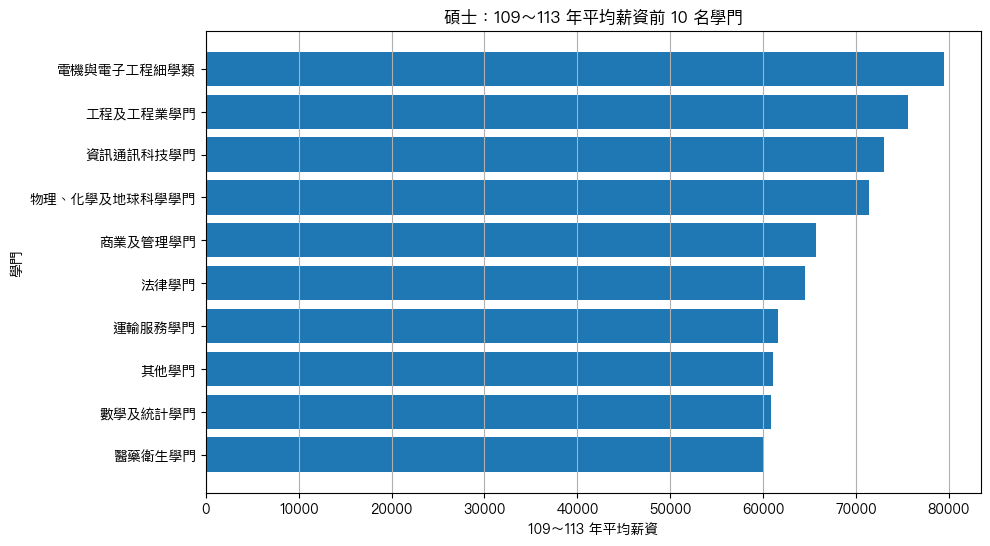

In [14]:
def plot_top_salary(df, degree, top_n=10):
    target = (
        df[df["學位"] == degree]
        .sort_values("五年平均薪資", ascending=False)
        .head(top_n)
        .sort_values("五年平均薪資")
    )

    plt.figure(figsize=(10, 6))
    plt.barh(target["學門"], target["五年平均薪資"])
    plt.title(f"{degree}：109～113 年平均薪資前 {top_n} 名學門")
    plt.xlabel("109～113 年平均薪資")
    plt.ylabel("學門")
    plt.grid(axis="x")
    plt.show()

plot_top_salary(analysis_df, "學士")
plot_top_salary(analysis_df, "碩士")

# 就讀人數前十名的圖


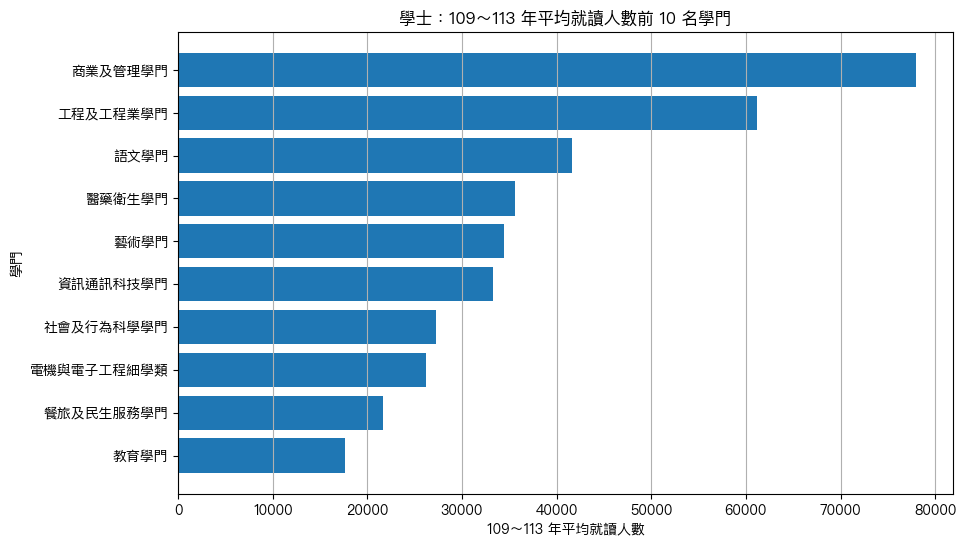

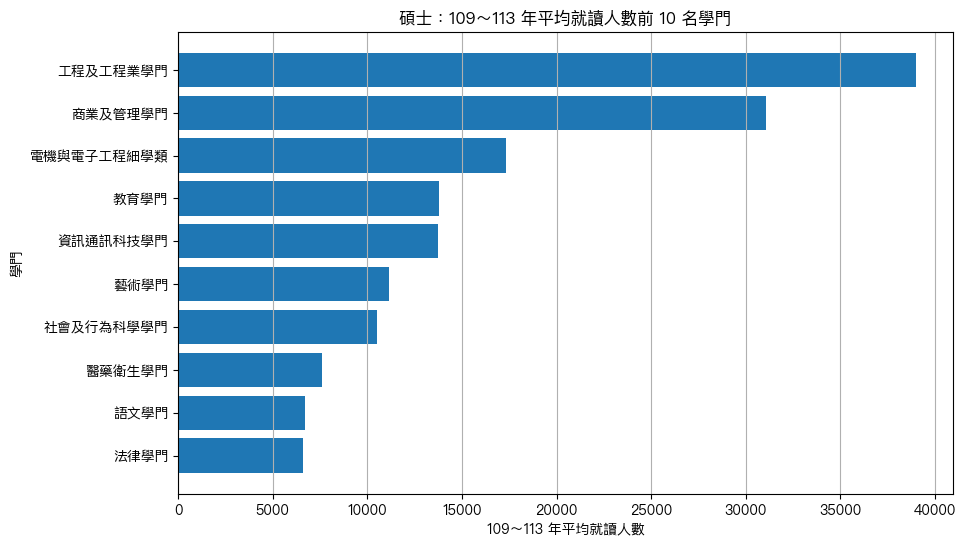

In [15]:
def plot_top_enrollment(df, degree, top_n=10):
    target = (
        df[df["學位"] == degree]
        .sort_values("五年平均就讀人數", ascending=False)
        .head(top_n)
        .sort_values("五年平均就讀人數")
    )

    plt.figure(figsize=(10, 6))
    plt.barh(target["學門"], target["五年平均就讀人數"])
    plt.title(f"{degree}：109～113 年平均就讀人數前 {top_n} 名學門")
    plt.xlabel("109～113 年平均就讀人數")
    plt.ylabel("學門")
    plt.grid(axis="x")
    plt.show()

plot_top_enrollment(analysis_df, "學士")
plot_top_enrollment(analysis_df, "碩士")

# 學碩士薪資差距


In [16]:
salary_compare = analysis_df.pivot(
    index="學門",
    columns="學位",
    values="五年平均薪資"
).reset_index()

salary_compare["碩士學士薪資差"] = salary_compare["碩士"] - salary_compare["學士"]

salary_compare.head()

學位,學門,學士,碩士,碩士學士薪資差
0,人文學門,38217.2,45447.2,7230.0
1,其他學門,46909.2,61047.6,14138.4
2,商業及管理學門,40304.2,65683.2,25379.0
3,安全服務學門,38199.8,NaN,NaN
4,工程及工程業學門,44809.0,75620.6,30811.6


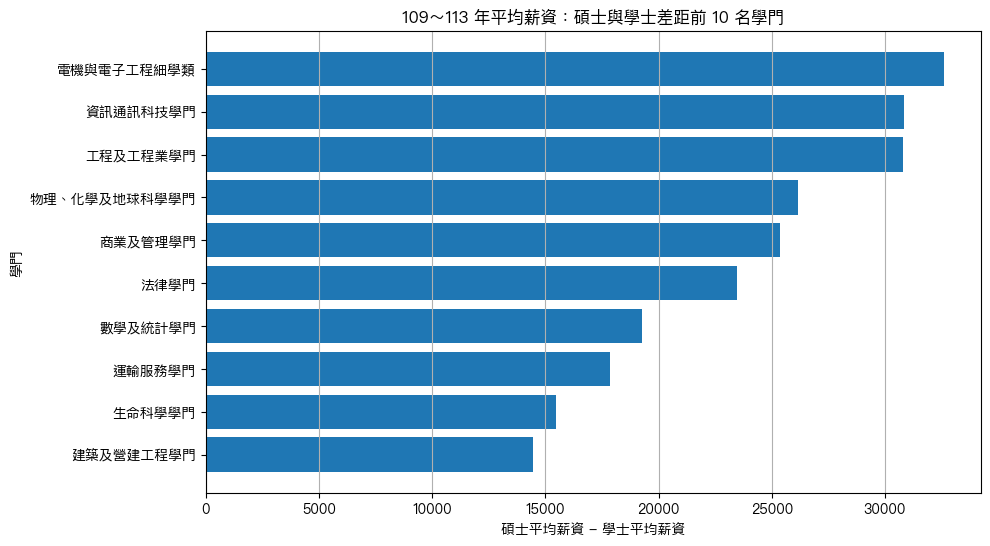

In [17]:
top_gap = (
    salary_compare
    .dropna()
    .sort_values("碩士學士薪資差", ascending=False)
    .head(10)
    .sort_values("碩士學士薪資差")
)

plt.figure(figsize=(10, 6))
plt.barh(top_gap["學門"], top_gap["碩士學士薪資差"])
plt.title("109～113 年平均薪資：碩士與學士差距前 10 名學門")
plt.xlabel("碩士平均薪資 - 學士平均薪資")
plt.ylabel("學門")
plt.grid(axis="x")
plt.show()

In [18]:
# === 電機電子（07141）薪資排名 與 碩學薪資差，跟其他學群比較 ===
# 1) 五年平均薪資排名（學士 / 碩士，越前面薪資越高）
for deg in ["學士", "碩士"]:
    d = (
        analysis_df[analysis_df["學位"] == deg]
        .dropna(subset=["五年平均薪資"])
        .sort_values("五年平均薪資", ascending=False)
        .reset_index(drop=True)
    )
    d["薪資排名"] = d.index + 1
    rank = int(d.loc[d["學門"] == EE_FIELD, "薪資排名"].iloc[0])
    print(f"【{deg}】電機電子五年平均薪資排名：第 {rank} / {len(d)} 個學群")
    print(d.head(5)[["薪資排名", "學門", "五年平均薪資"]].to_string(index=False))
    print()

# 2) 碩士-學士薪資差排名（salary_compare 來自上方學碩士薪資差距區段）
gap = (
    salary_compare
    .dropna(subset=["碩士學士薪資差"])
    .sort_values("碩士學士薪資差", ascending=False)
    .reset_index(drop=True)
)
gap["差距排名"] = gap.index + 1
gap["差距%"] = (gap["碩士"] / gap["學士"] - 1) * 100
ee = gap[gap["學門"] == EE_FIELD].iloc[0]
print(
    f"【碩學薪資差】電機電子：學士 {ee['學士']:,.0f} → 碩士 {ee['碩士']:,.0f}，"
    f"差 {ee['碩士學士薪資差']:,.0f} 元 (+{ee['差距%']:.1f}%)，"
    f"差距排名第 {int(ee['差距排名'])} / {len(gap)} 個學群"
)
print(
    gap.head(5)[["差距排名", "學門", "學士", "碩士", "碩士學士薪資差", "差距%"]]
    .round(1).to_string(index=False)
)

【學士】電機電子五年平均薪資排名：第 3 / 28 個學群
 薪資排名           學門   五年平均薪資
    1       醫藥衛生學門 52931.20
    2         其他學門 46909.20
    3   電機與電子工程細學類 46847.75
    4 物理、化學及地球科學學門 45178.60
    5     工程及工程業學門 44809.00

【碩士】電機電子五年平均薪資排名：第 1 / 27 個學群
 薪資排名           學門  五年平均薪資
    1   電機與電子工程細學類 79450.5
    2     工程及工程業學門 75620.6
    3     資訊通訊科技學門 72966.2
    4 物理、化學及地球科學學門 71358.4
    5      商業及管理學門 65683.2

【碩學薪資差】電機電子：學士 46,848 → 碩士 79,450，差 32,603 元 (+69.6%)，差距排名第 1 / 27 個學群
 差距排名           學門      學士      碩士  碩士學士薪資差  差距%
    1   電機與電子工程細學類 46847.8 79450.5  32602.8 69.6
    2     資訊通訊科技學門 42142.4 72966.2  30823.8 73.1
    3     工程及工程業學門 44809.0 75620.6  30811.6 68.8
    4 物理、化學及地球科學學門 45178.6 71358.4  26179.8 57.9
    5      商業及管理學門 40304.2 65683.2  25379.0 63.0


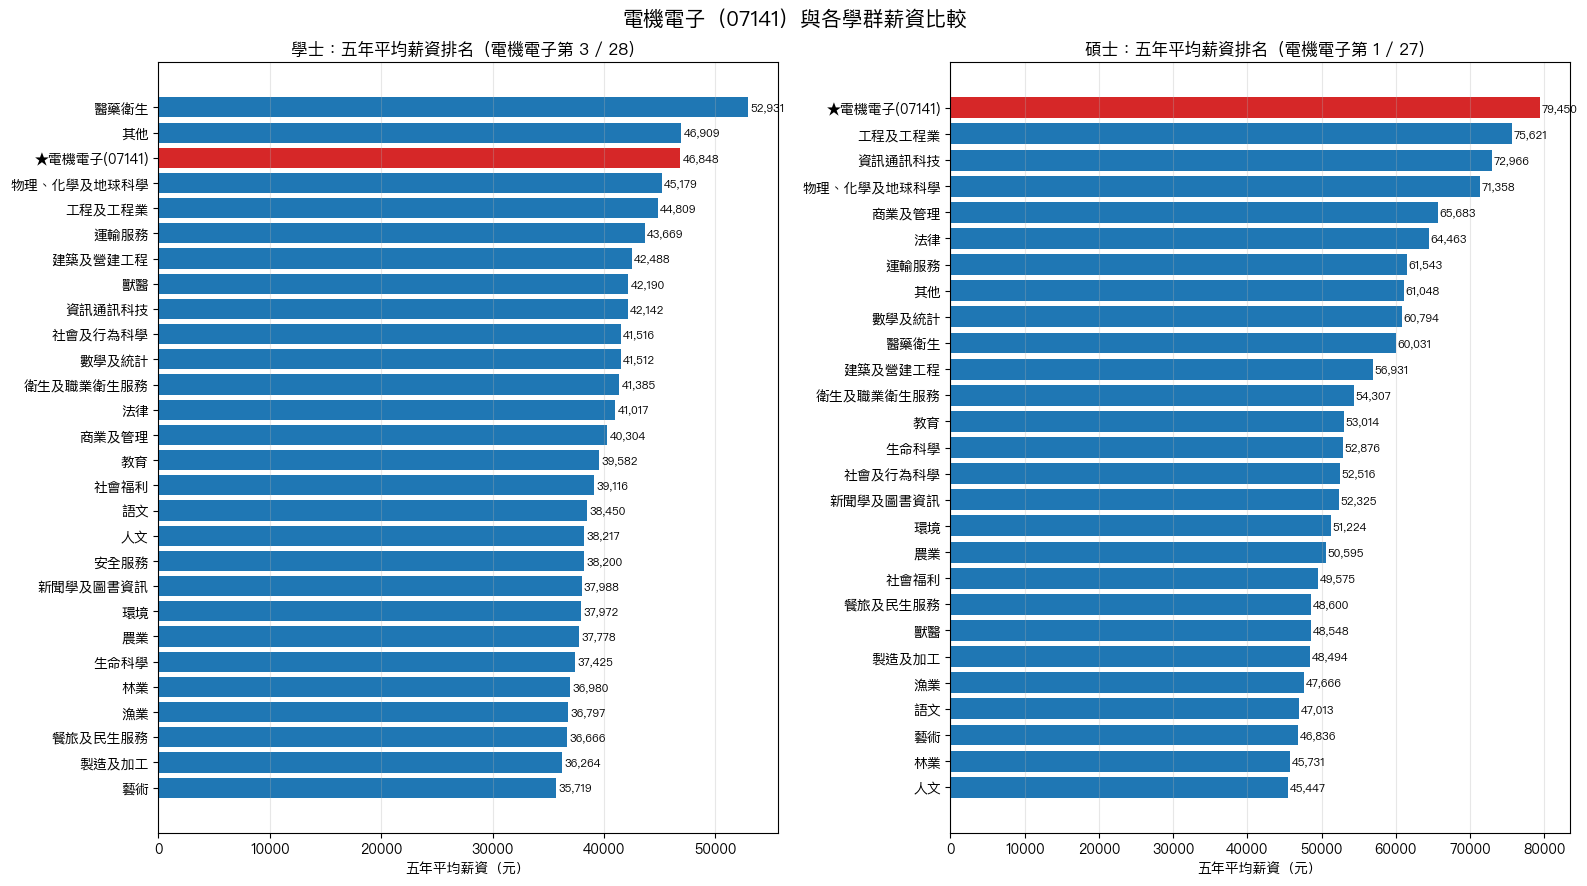

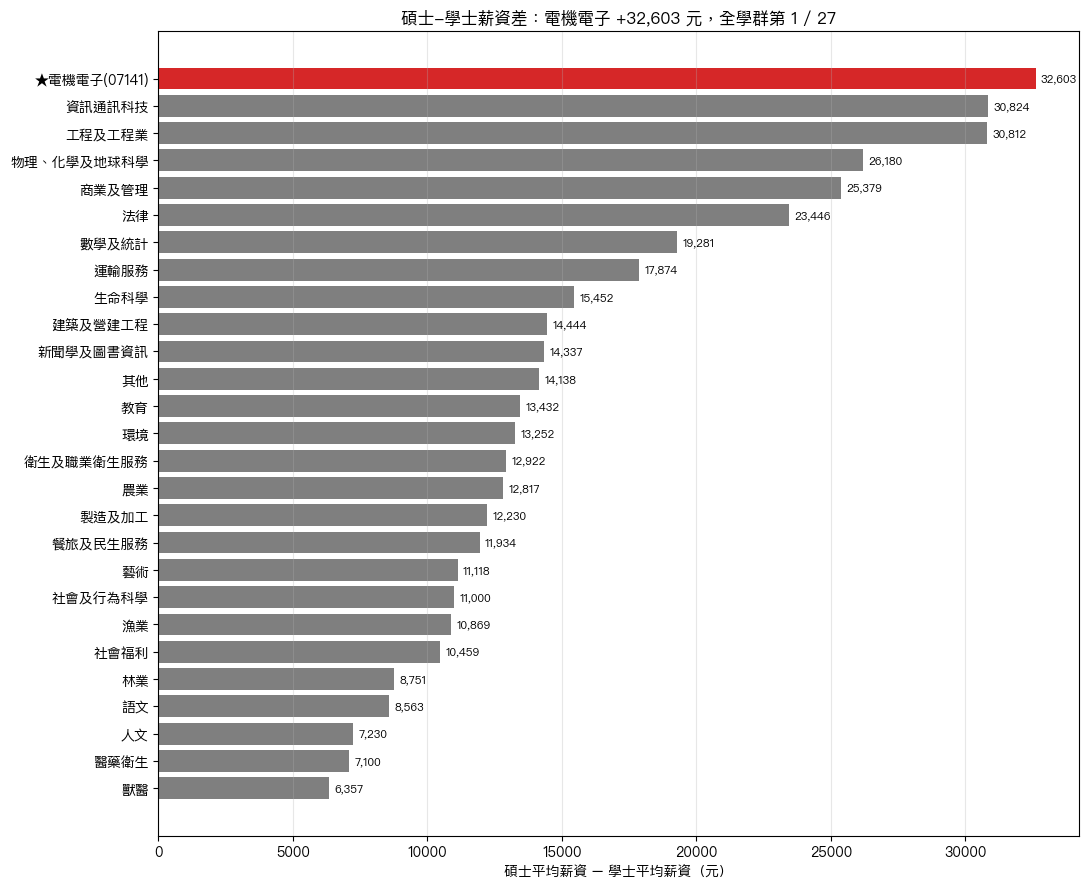

In [19]:
# === 視覺化：電機電子 vs 其他學群（薪資排名 + 碩學差），紅色 = 電機電子 ===
def _label(name):
    return "★電機電子(07141)" if name == EE_FIELD else name.replace("學門", "")

# 圖一：學士 / 碩士 五年平均薪資排名（全學群橫向長條）
fig, axes = plt.subplots(1, 2, figsize=(16, 9))
for ax, deg in zip(axes, ["學士", "碩士"]):
    d = (
        analysis_df[analysis_df["學位"] == deg]
        .dropna(subset=["五年平均薪資"])
        .sort_values("五年平均薪資")
    )
    colors = ["tab:red" if n == EE_FIELD else "tab:blue" for n in d["學門"]]
    bars = ax.barh([_label(n) for n in d["學門"]], d["五年平均薪資"], color=colors)
    for b, v in zip(bars, d["五年平均薪資"]):
        ax.text(v + 200, b.get_y() + b.get_height() / 2, f"{v:,.0f}",
                va="center", fontsize=8)
    rank = (d["五年平均薪資"] >= d.loc[d["學門"] == EE_FIELD, "五年平均薪資"].iloc[0]).sum()
    ax.set_title(f"{deg}：五年平均薪資排名（電機電子第 {rank} / {len(d)}）")
    ax.set_xlabel("五年平均薪資（元）")
    ax.grid(axis="x", alpha=0.3)
fig.suptitle("電機電子（07141）與各學群薪資比較", fontsize=15)
fig.tight_layout()
plt.show()

# 圖二：碩士-學士薪資差（全學群橫向長條）
gp = (
    salary_compare
    .dropna(subset=["碩士學士薪資差"])
    .sort_values("碩士學士薪資差")
)
plt.figure(figsize=(11, 9))
colors = ["tab:red" if n == EE_FIELD else "tab:gray" for n in gp["學門"]]
bars = plt.barh([_label(n) for n in gp["學門"]], gp["碩士學士薪資差"], color=colors)
for b, v in zip(bars, gp["碩士學士薪資差"]):
    plt.text(v + 200, b.get_y() + b.get_height() / 2, f"{v:,.0f}",
             va="center", fontsize=8)
ee_rank = (gp["碩士學士薪資差"] >= gp.loc[gp["學門"] == EE_FIELD, "碩士學士薪資差"].iloc[0]).sum()
plt.title(f"碩士-學士薪資差：電機電子 +{gp.loc[gp['學門']==EE_FIELD,'碩士學士薪資差'].iloc[0]:,.0f} 元，"
          f"全學群第 {ee_rank} / {len(gp)}")
plt.xlabel("碩士平均薪資 − 學士平均薪資（元）")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# 逐年相關性趨勢

看 109～113 每一年，各學門「就讀人數」與「薪資」是不是正相關

- 就讀人數：該年份各學門學生數加總
- 薪資：該年畢業生在最新統計期的薪資
- 每一年算一次跨學門的 Pearson / Spearman 相關係數，再畫成趨勢圖

In [20]:
def prepare_salary_yearly(df):
    df = df.copy()

    df["薪資"] = pd.to_numeric(df["薪資"], errors="coerce")

    df["畢業年份"] = (
        df["畢業年"]
        .astype(str)
        .str.extract(r"(\d+)")[0]
        .astype(int)
    )

    df["統計期_year"] = (
        df["統計期"]
        .astype(str)
        .str.extract(r"(\d+)年")[0]
        .astype(int)
    )

    df["統計期_month"] = (
        df["統計期"]
        .astype(str)
        .str.extract(r"年\s*(\d+)月")[0]
        .astype(int)
    )

    df = df[df["畢業年份"].between(109, 113)]

    # 每個學位 x 學門 x 畢業年份，只留最新統計期的薪資
    latest_salary = (
        df.sort_values(["統計期_year", "統計期_month"])
        .groupby(["學位", "學門", "畢業年份"], as_index=False)
        .tail(1)
    )

    return latest_salary[["學位", "學門", "畢業年份", "薪資"]]

salary_yearly = pd.concat(
    [
        prepare_salary_yearly(salary_bachelor_df),
        prepare_salary_yearly(salary_master_df)
    ],
    ignore_index=True
)

# 就讀年份對應畢業年份，合併每年的人數與薪資
yearly_df = enroll_yearly.merge(
    salary_yearly,
    left_on=["學位", "年份", "學門"],
    right_on=["學位", "畢業年份", "學門"],
    how="inner"
)

corr_rows = []

for (degree, year), group in (
    yearly_df
    .dropna(subset=["學生數", "薪資"])
    .groupby(["學位", "年份"])
):
    pearson_result = pearsonr(group["學生數"], group["薪資"])
    spearman_result = spearmanr(group["學生數"], group["薪資"])

    corr_rows.append({
        "學位": degree,
        "年份": year,
        "學門數": len(group),
        "Pearson": pearson_result.statistic,
        "Pearson_p": pearson_result.pvalue,
        "Spearman": spearman_result.statistic,
        "Spearman_p": spearman_result.pvalue,
    })

corr_trend = pd.DataFrame(corr_rows)

corr_trend.round(3)

,學位,年份,學門數,Pearson,Pearson_p,Spearman,Spearman_p
0,學士,109,27,0.078,0.700,0.106,0.598
1,學士,110,28,0.227,0.245,0.202,0.303
2,學士,111,28,0.250,0.200,0.267,0.169
3,學士,112,28,0.285,0.141,0.263,0.176
4,學士,113,28,0.312,0.106,0.261,0.180
5,碩士,109,26,0.532,0.005,0.369,0.064
6,碩士,110,27,0.578,0.002,0.369,0.058
7,碩士,111,27,0.524,0.005,0.319,0.105
8,碩士,112,27,0.571,0.002,0.435,0.023
9,碩士,113,27,0.671,0.000,0.560,0.002


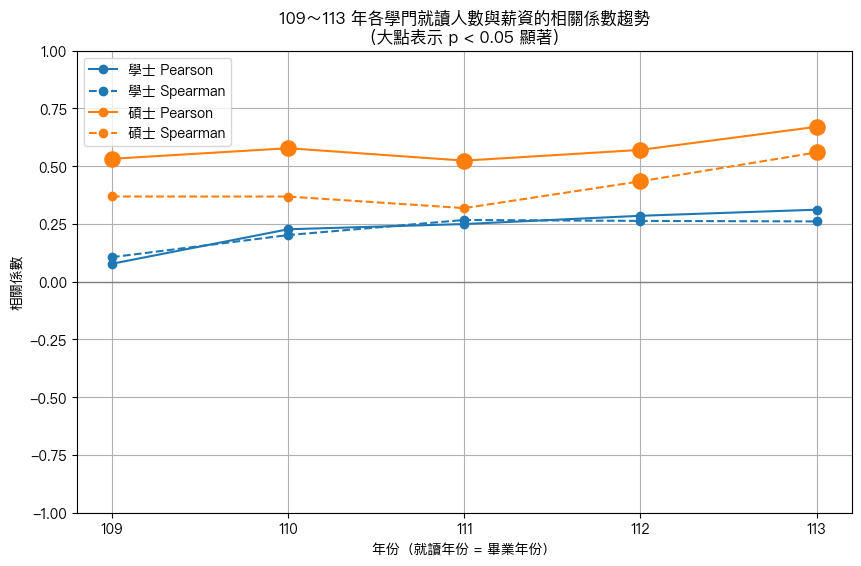

In [21]:
def plot_corr_trend(df):
    plt.figure(figsize=(10, 6))

    styles = {
        ("學士", "Pearson"): {"color": "tab:blue", "linestyle": "-"},
        ("學士", "Spearman"): {"color": "tab:blue", "linestyle": "--"},
        ("碩士", "Pearson"): {"color": "tab:orange", "linestyle": "-"},
        ("碩士", "Spearman"): {"color": "tab:orange", "linestyle": "--"},
    }

    for (degree, method), style in styles.items():
        target = df[df["學位"] == degree].sort_values("年份")

        plt.plot(
            target["年份"],
            target[method],
            marker="o",
            label=f"{degree} {method}",
            **style
        )

        # p < 0.05 的年份用實心大點標記
        significant = target[target[f"{method}_p"] < 0.05]
        plt.scatter(
            significant["年份"],
            significant[method],
            s=120,
            color=style["color"],
            zorder=3
        )

    plt.axhline(0, color="gray", linewidth=1)
    plt.title("109～113 年各學門就讀人數與薪資的相關係數趨勢\n（大點表示 p < 0.05 顯著）")
    plt.xlabel("年份（就讀年份 = 畢業年份）")
    plt.ylabel("相關係數")
    plt.xticks(df["年份"].unique())
    plt.ylim(-1, 1)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_corr_trend(corr_trend)

# 目標學門趨勢：資工（資訊通訊科技學門）

只看「資訊通訊科技學門」自己一個學門，觀察 109～113 五年間
**就讀人數** 與 **薪資** 是不是一起往上走（時間序列上的正相關）。

- 左軸：當年就讀人數
- 右軸：該年畢業生在最新統計期的薪資
- 同時算這五年人數與薪資的 Pearson 相關係數

> 注意：薪資是依「畢業年份」對齊的，較早畢業（109）的人在最新統計期已有較多年資、薪資較高；
> 較晚畢業（113）的多為社會新鮮人、薪資偏低。所以單一學門的「人數 vs 薪資」會受到年資因素干擾，解讀時要留意。

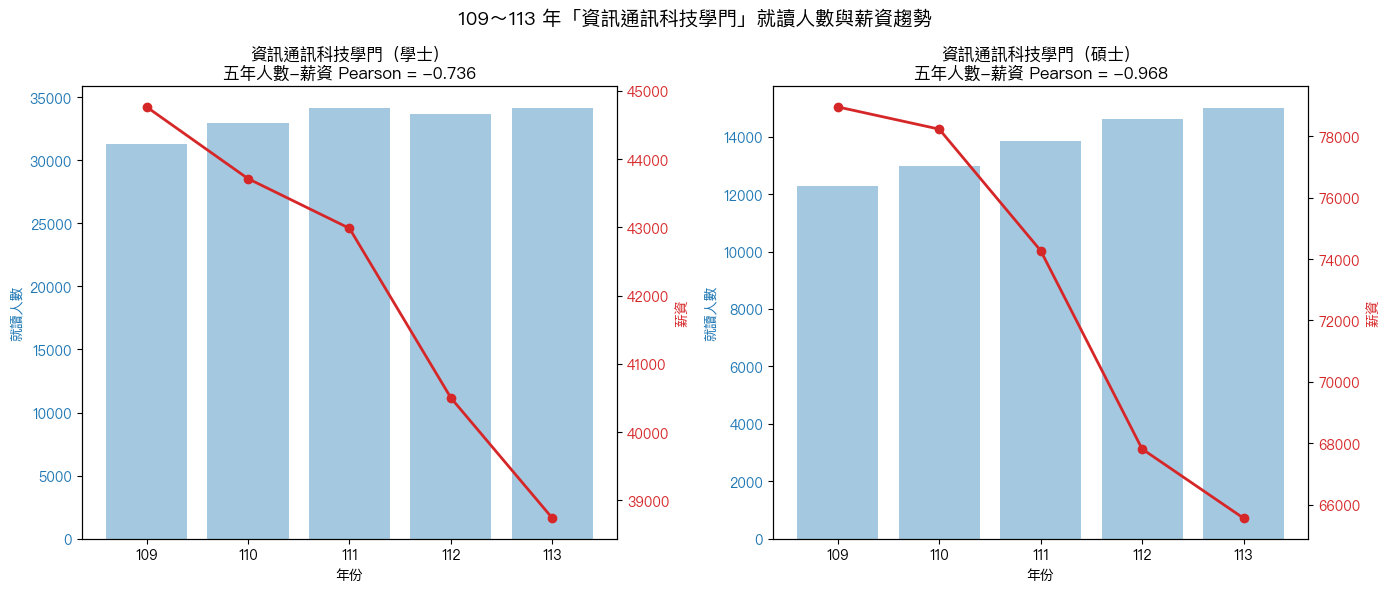

In [22]:
TARGET_FIELD = "資訊通訊科技學門"

def plot_single_field_trend(df, field):
    target_all = df[df["學門"] == field].sort_values(["學位", "年份"])

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

    for ax, degree in zip(axes, ["學士", "碩士"]):
        g = target_all[target_all["學位"] == degree]

        # 左軸：就讀人數（長條）
        ax.bar(
            g["年份"], g["學生數"],
            color="tab:blue", alpha=0.4, label="就讀人數"
        )
        ax.set_ylabel("就讀人數", color="tab:blue")
        ax.tick_params(axis="y", labelcolor="tab:blue")
        ax.set_xlabel("年份")
        ax.set_xticks(g["年份"])

        # 右軸：薪資（折線）
        ax2 = ax.twinx()
        ax2.plot(
            g["年份"], g["薪資"],
            color="tab:red", marker="o", linewidth=2, label="薪資"
        )
        ax2.set_ylabel("薪資", color="tab:red")
        ax2.tick_params(axis="y", labelcolor="tab:red")

        # 這五年人數與薪資的相關係數
        r = pearsonr(g["學生數"], g["薪資"]).statistic
        ax.set_title(f"{field}（{degree}）\n五年人數-薪資 Pearson = {r:.3f}")

    fig.suptitle(f"109～113 年「{field}」就讀人數與薪資趨勢", fontsize=14)
    fig.tight_layout()
    plt.show()

plot_single_field_trend(yearly_df, TARGET_FIELD)

# 呈現方式改良

## 改良 1：逐年散布圖（取代抽象的係數折線）

相關係數折線圖適合當總結，但觀眾看不出「正相關長什麼樣」。
這裡改用 2×5 的小倍數散布圖：每一年一格、學士碩士各一排，
x 軸取對數（人數從數百到數萬，差兩個數量級），並把資工（資訊通訊科技學門）標成紅星。

一張圖同時回答兩件事：
1. 每一年跨學門「人數 vs 薪資」是不是正相關（看點的分布方向 + 標題的 r）
2. 資工在所有學門中的相對位置（人數偏多、薪資偏高）

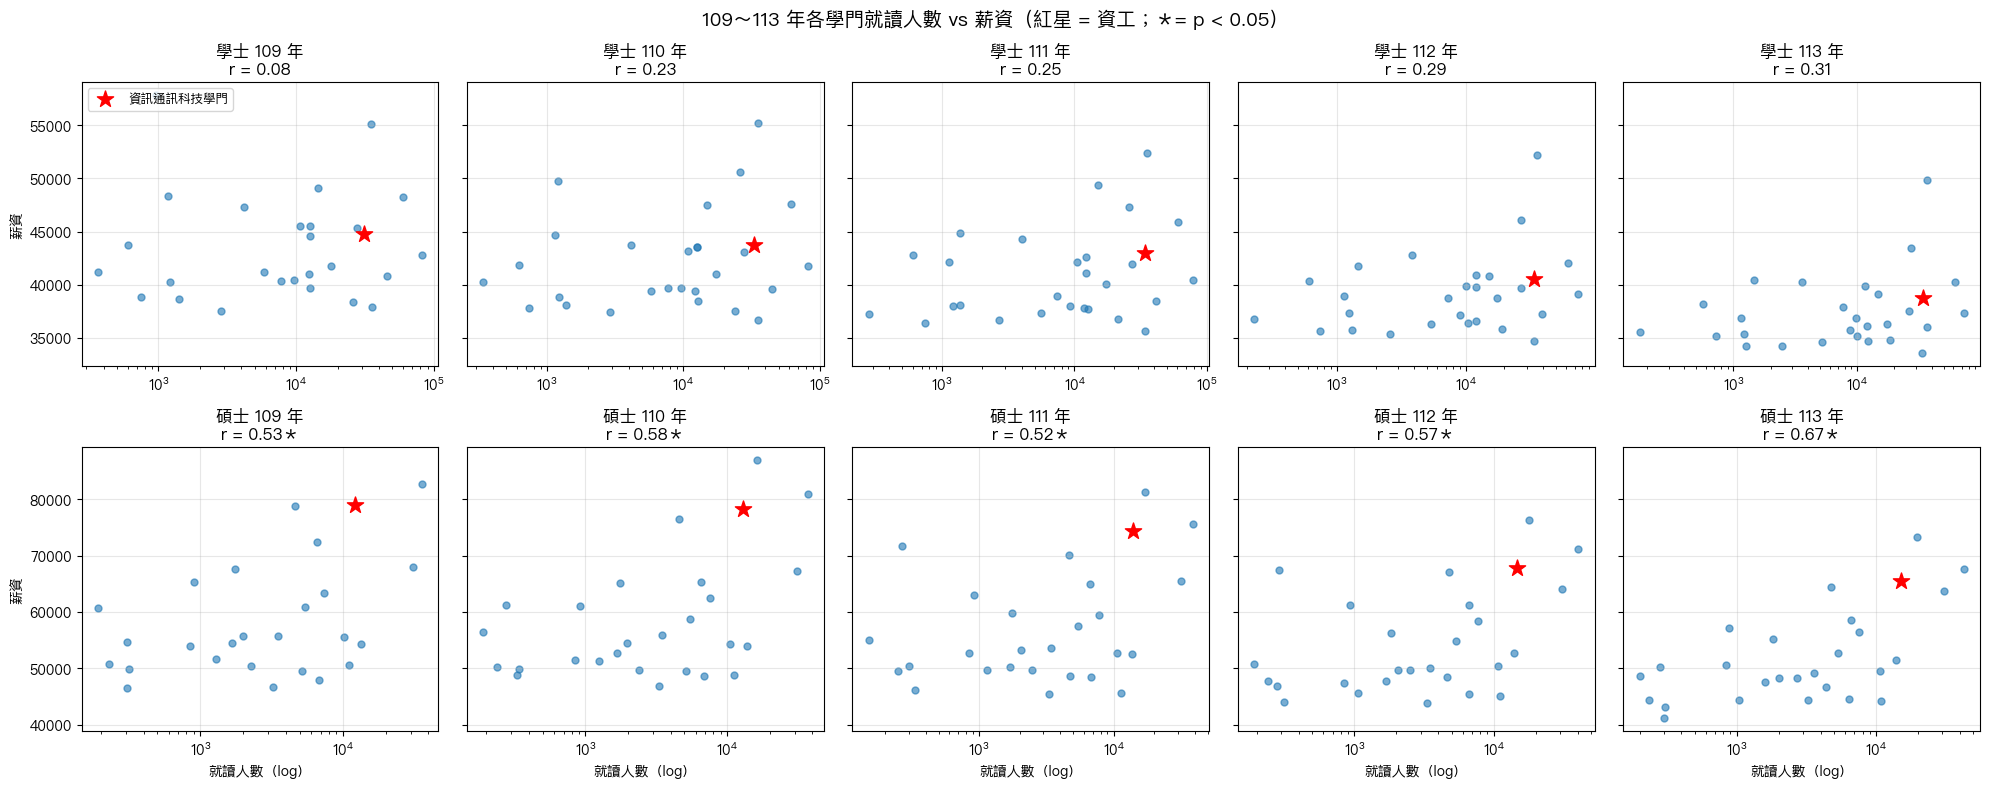

In [23]:
def plot_yearly_scatter_grid(df, corr_df, highlight=TARGET_FIELD):
    years = sorted(df["年份"].unique())

    fig, axes = plt.subplots(
        2, len(years),
        figsize=(20, 8),
        sharey="row"
    )

    for row, degree in enumerate(["學士", "碩士"]):
        for col, year in enumerate(years):
            ax = axes[row, col]

            g = (
                df[(df["學位"] == degree) & (df["年份"] == year)]
                .dropna(subset=["學生數", "薪資"])
            )
            others = g[g["學門"] != highlight]
            target = g[g["學門"] == highlight]

            ax.scatter(
                others["學生數"], others["薪資"],
                alpha=0.6, s=25, color="tab:blue"
            )
            ax.scatter(
                target["學生數"], target["薪資"],
                color="red", s=150, marker="*",
                zorder=3, label="資訊通訊科技學門"
            )

            ax.set_xscale("log")

            stat = corr_df[
                (corr_df["學位"] == degree) & (corr_df["年份"] == year)
            ].iloc[0]
            star = "＊" if stat["Pearson_p"] < 0.05 else ""
            ax.set_title(f"{degree} {year} 年\nr = {stat['Pearson']:.2f}{star}")

            ax.grid(True, alpha=0.3)
            if col == 0:
                ax.set_ylabel("薪資")
            if row == 1:
                ax.set_xlabel("就讀人數（log）")

    axes[0, 0].legend(loc="upper left", fontsize=9)
    fig.suptitle(
        "109～113 年各學門就讀人數 vs 薪資（紅星 = 資工；＊= p < 0.05）",
        fontsize=14
    )
    fig.tight_layout()
    plt.show()

plot_yearly_scatter_grid(yearly_df, corr_trend)

## 改良 2：資工薪資軌跡圖（修正年資干擾）

前面的資工雙軸圖算出負相關，但那主要是「年資效果」：
取最新統計期時，109 屆已工作約 5 年、113 屆才約 1 年，薪資當然遞減。

這裡改成兩層呈現：

- **上排**：每一屆畢業生的薪資成長軌跡（x = 統計期）。同一條線往上走 = 同屆隨年資加薪；
  不同線之間的高度差才是「屆與屆的差異」。
- **下排**：固定年資比較，兩條線——
  - **新鮮人薪資**（綠線）：畢業當年 7 月統計期，年資約 0 年。資料從 112 年 1 月開始，所以只有 112、113 屆有值。
  - **畢業滿一年薪資**（紅線）：畢業次年 7 月統計期，年資約 1 年，111～113 屆有值。

  搭配藍色長條的當年就讀人數。

這樣可以看出：人數逐年增加的同時，新鮮人起薪和滿一年薪資都**沒有下降**
（學士兩條線都逐屆上升，碩士大致持平），跟雙軸圖表面上的負相關結論完全不同。

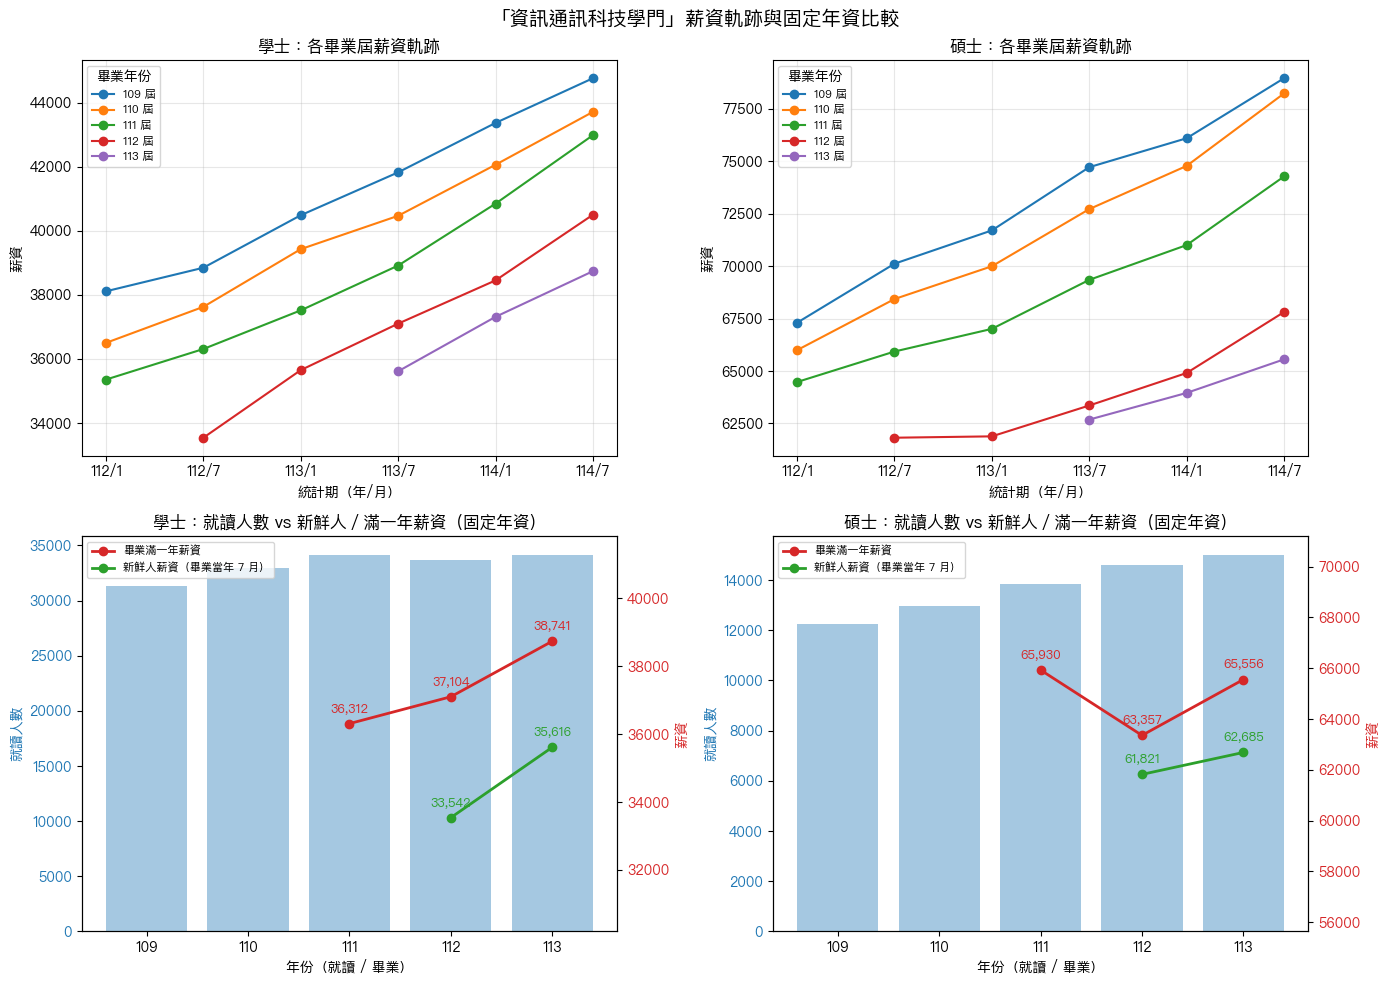

In [24]:
def prepare_salary_periods(df, degree):
    df = df.copy()

    df["薪資"] = pd.to_numeric(df["薪資"], errors="coerce")

    df["畢業年份"] = (
        df["畢業年"].astype(str).str.extract(r"(\d+)")[0].astype(int)
    )
    df["統計期_year"] = (
        df["統計期"].astype(str).str.extract(r"(\d+)年")[0].astype(int)
    )
    df["統計期_month"] = (
        df["統計期"].astype(str).str.extract(r"年\s*(\d+)月")[0].astype(int)
    )

    df = df[df["畢業年份"].between(109, 113)]
    df["學位"] = degree

    # 統計期換算成數線位置，1 月在年初、7 月在年中
    df["統計期位置"] = df["統計期_year"] + (df["統計期_month"] - 1) / 12

    return df

salary_periods = pd.concat(
    [
        prepare_salary_periods(salary_bachelor_df, "學士"),
        prepare_salary_periods(salary_master_df, "碩士")
    ],
    ignore_index=True
)

def plot_field_trajectory(field):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    for col, degree in enumerate(["學士", "碩士"]):
        target = salary_periods[
            (salary_periods["學門"] == field)
            & (salary_periods["學位"] == degree)
        ].sort_values(["畢業年份", "統計期位置"])

        # 上排：各畢業屆薪資軌跡
        ax = axes[0, col]
        for cohort, g in target.groupby("畢業年份"):
            ax.plot(
                g["統計期位置"], g["薪資"],
                marker="o", label=f"{cohort} 屆"
            )

        tick_pos = sorted(target["統計期位置"].unique())
        ax.set_xticks(tick_pos)
        ax.set_xticklabels(
            [f"{int(p)}/{1 if p == int(p) else 7}" for p in tick_pos]
        )
        ax.set_title(f"{degree}：各畢業屆薪資軌跡")
        ax.set_xlabel("統計期（年/月）")
        ax.set_ylabel("薪資")
        ax.legend(title="畢業年份", fontsize=8)
        ax.grid(True, alpha=0.3)

        # 下排：固定年資薪資 vs 就讀人數
        # 新鮮人 = 畢業當年 7 月統計期（年資約 0 年，僅 112、113 屆有資料）
        fresh = target[
            (target["統計期_year"] == target["畢業年份"])
            & (target["統計期_month"] == 7)
        ].sort_values("畢業年份")

        # 滿一年 = 畢業次年 7 月統計期（年資約 1 年，111～113 屆有資料）
        one_year = target[
            (target["統計期_year"] == target["畢業年份"] + 1)
            & (target["統計期_month"] == 7)
        ].sort_values("畢業年份")

        enroll = (
            yearly_df[
                (yearly_df["學門"] == field)
                & (yearly_df["學位"] == degree)
            ]
            .sort_values("年份")
        )

        ax = axes[1, col]
        ax.bar(
            enroll["年份"], enroll["學生數"],
            color="tab:blue", alpha=0.4
        )
        ax.set_ylabel("就讀人數", color="tab:blue")
        ax.tick_params(axis="y", labelcolor="tab:blue")
        ax.set_xlabel("年份（就讀 / 畢業）")
        ax.set_xticks(enroll["年份"])

        ax2 = ax.twinx()
        for line_df, color, label in [
            (one_year, "tab:red", "畢業滿一年薪資"),
            (fresh, "tab:green", "新鮮人薪資（畢業當年 7 月）"),
        ]:
            ax2.plot(
                line_df["畢業年份"], line_df["薪資"],
                color=color, marker="o", linewidth=2, label=label
            )
            for _, r in line_df.iterrows():
                ax2.annotate(
                    f"{r['薪資']:,.0f}",
                    (r["畢業年份"], r["薪資"]),
                    textcoords="offset points", xytext=(0, 8),
                    ha="center", fontsize=9, color=color
                )

        ax2.set_ylabel("薪資", color="tab:red")
        ax2.tick_params(axis="y", labelcolor="tab:red")

        # 拉開薪資軸範圍，避免幾 % 的差異被視覺放大
        salary_values = pd.concat([one_year["薪資"], fresh["薪資"]])
        ax2.set_ylim(
            salary_values.min() * 0.90,
            salary_values.max() * 1.08
        )
        ax2.legend(loc="upper left", fontsize=8)

        ax.set_title(f"{degree}：就讀人數 vs 新鮮人／滿一年薪資（固定年資）")

    fig.suptitle(f"「{field}」薪資軌跡與固定年資比較", fontsize=14)
    fig.tight_layout()
    plt.show()

plot_field_trajectory(TARGET_FIELD)

# 目標細學類趨勢：電機電子（電機與電子工程細學類 07141）

把工程學門裡的電機電子（細學類 07141）單獨拉出來，沿用前面資工的兩套呈現方式：

1. **就讀人數 vs 薪資雙軸趨勢**（`plot_single_field_trend`）：左軸當年就讀人數、右軸該屆在最新統計期的薪資。
2. **薪資軌跡 + 固定年資比較**（`plot_field_trajectory`）：上排各畢業屆薪資成長軌跡，下排就讀人數搭配新鮮人／滿一年薪資。

> 資料限制：07141 細學類薪資只從 113 年 1 月開始，序列比學門級短，
> 「新鮮人薪資」只有 113 屆、「滿一年薪資」只有 112、113 屆，因此薪資軌跡圖會比資工稀疏；
> 雙漲象限圖（需要 111 屆滿一年薪資）則因缺資料不會出現電機電子的點。

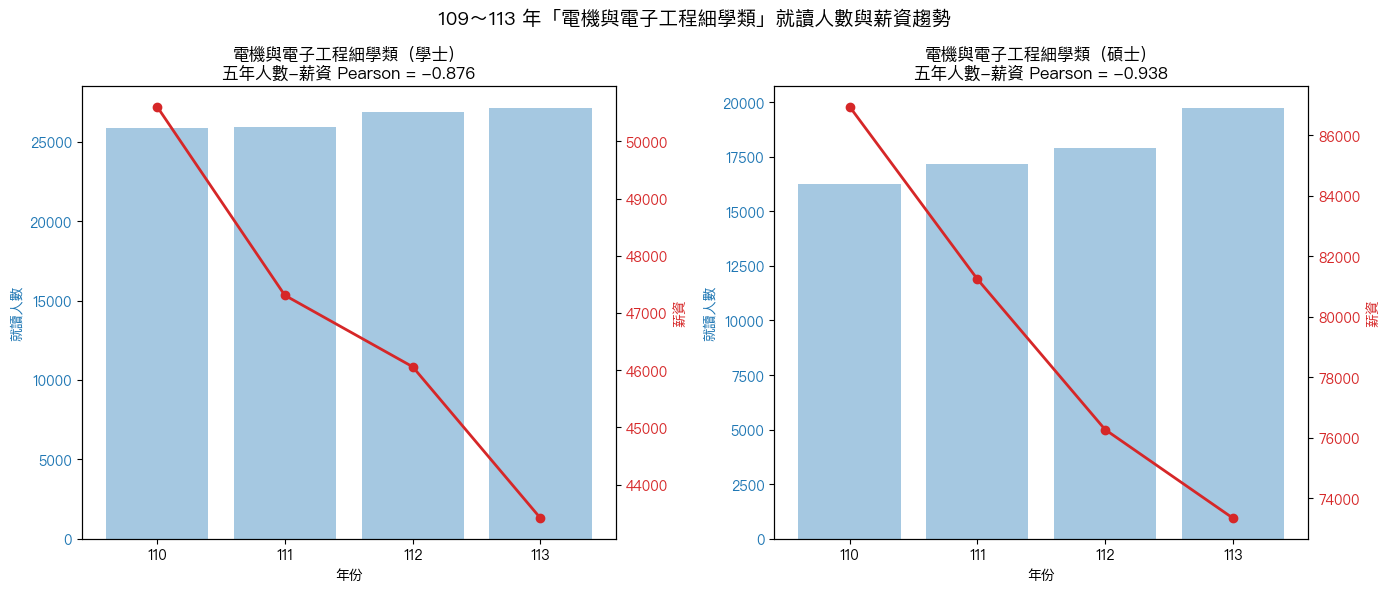

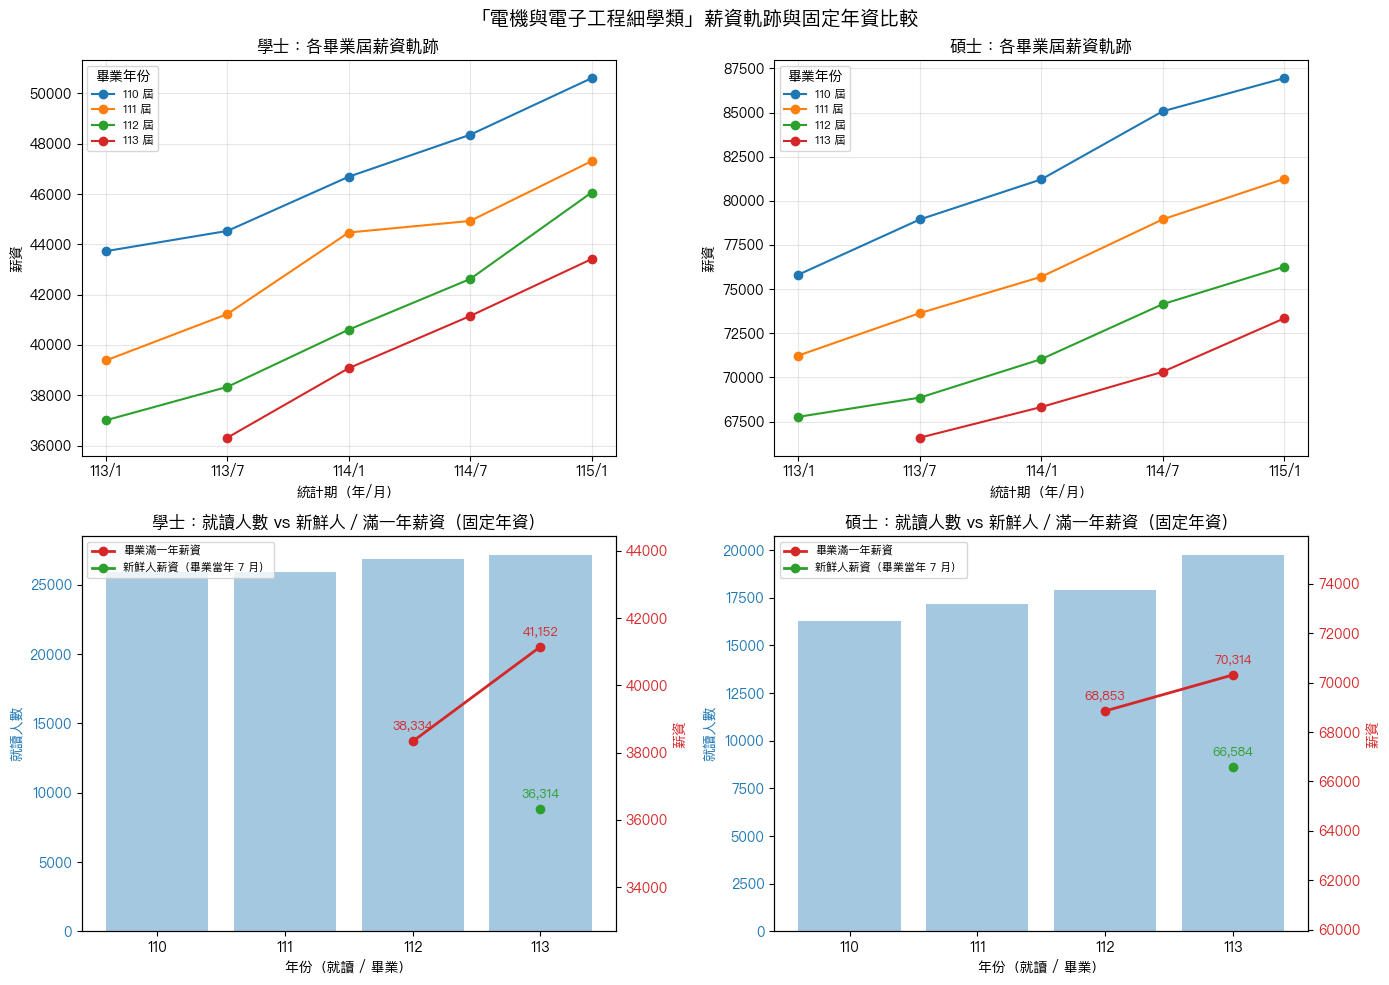

In [25]:
# 沿用前面資工的兩個函式，把目標換成電機電子細學類
plot_single_field_trend(yearly_df, EE_FIELD)
plot_field_trajectory(EE_FIELD)

# 延伸分析：藍海學門（薪資高、人少）

找出「就讀人數少、但薪資高」的學門，當成選系／轉領域的參考。

**藍海指數** =（薪資百分位 + 人少百分位）÷ 2，學士碩士分開排名：

- 薪資：113 屆畢業生在最新統計期（114 年 7 月）的薪資，年資約一年，所有學門基準一致
- 人數：109～113 年的五年平均就讀人數，人越少分數越高
- 另附 109 屆畢業生工作約五年後的薪資，看各學門的薪資成長天花板

注意：「其他學門」是統計上的雜項分類（歸不進其他學門的科系），不是實際可就讀的單一領域，解讀時跳過。

In [26]:
enroll_avg = (
    yearly_df
    .groupby(["學位", "學門"], as_index=False)["學生數"]
    .mean()
    .rename(columns={"學生數": "五年平均人數"})
)

sal_113 = (
    yearly_df[yearly_df["年份"] == 113][["學位", "學門", "薪資"]]
    .rename(columns={"薪資": "薪資_113屆"})
)
sal_109 = (
    yearly_df[yearly_df["年份"] == 109][["學位", "學門", "薪資"]]
    .rename(columns={"薪資": "薪資_109屆五年後"})
)

blue_ocean = (
    enroll_avg
    .merge(sal_113, on=["學位", "學門"], how="left")
    .merge(sal_109, on=["學位", "學門"], how="left")
    .dropna(subset=["薪資_113屆"])
)

blue_ocean["薪資百分位"] = (
    blue_ocean.groupby("學位")["薪資_113屆"].rank(pct=True)
)
blue_ocean["稀少百分位"] = (
    blue_ocean.groupby("學位")["五年平均人數"].rank(pct=True, ascending=False)
)
blue_ocean["藍海指數"] = (
    (blue_ocean["薪資百分位"] + blue_ocean["稀少百分位"]) / 2
)

for degree in ["學士", "碩士"]:
    top = (
        blue_ocean[blue_ocean["學位"] == degree]
        .sort_values("藍海指數", ascending=False)
        .head(8)
    )
    print(f"===== {degree}：藍海指數前 8 名 =====")
    print(
        top[["學門", "五年平均人數", "薪資_113屆", "薪資_109屆五年後", "藍海指數"]]
        .round(2)
        .to_string(index=False)
    )

    ranked = (
        blue_ocean[blue_ocean["學位"] == degree]
        .sort_values("藍海指數", ascending=False)["學門"]
        .tolist()
    )
    print(f"（參考）{TARGET_FIELD} 排名：{ranked.index(TARGET_FIELD) + 1}/{len(ranked)}")
    print()

===== 學士：藍海指數前 8 名 =====
         學門  五年平均人數  薪資_113屆  薪資_109屆五年後  藍海指數
       其他學門  1295.2  40446.0     57818.0  0.88
衛生及職業衛生服務學門   600.8  38180.0     43749.0  0.84
     運輸服務學門  3964.6  40290.0     47276.0  0.80
       獸醫學門  1152.8  36913.0     48304.0  0.73
     安全服務學門   277.8  35528.0     41208.0  0.68
     社會福利學門  7572.2  37870.0     40306.0  0.66
  建築及營建工程學門 12240.8  39838.0     45489.0  0.66
 電機與電子工程細學類 26463.0  43414.0         NaN  0.62
（參考）資訊通訊科技學門 排名：15/28

===== 碩士：藍海指數前 8 名 =====
          學門  五年平均人數  薪資_113屆  薪資_109屆五年後  藍海指數
      運輸服務學門   907.0  57196.0     65243.0  0.78
        其他學門   283.6  50305.0     54743.0  0.74
 衛生及職業衛生服務學門   184.8  48613.0     60693.0  0.72
        環境學門   840.4  50582.0     53886.0  0.70
     數學及統計學門  1776.2  55265.0     67613.0  0.69
物理、化學及地球科學學門  4681.6  64397.0     78794.0  0.69
        法律學門  6614.4  58506.0     72329.0  0.59
        獸醫學門   238.0  44423.0     50696.0  0.57
（參考）資訊通訊科技學門 排名：10/27



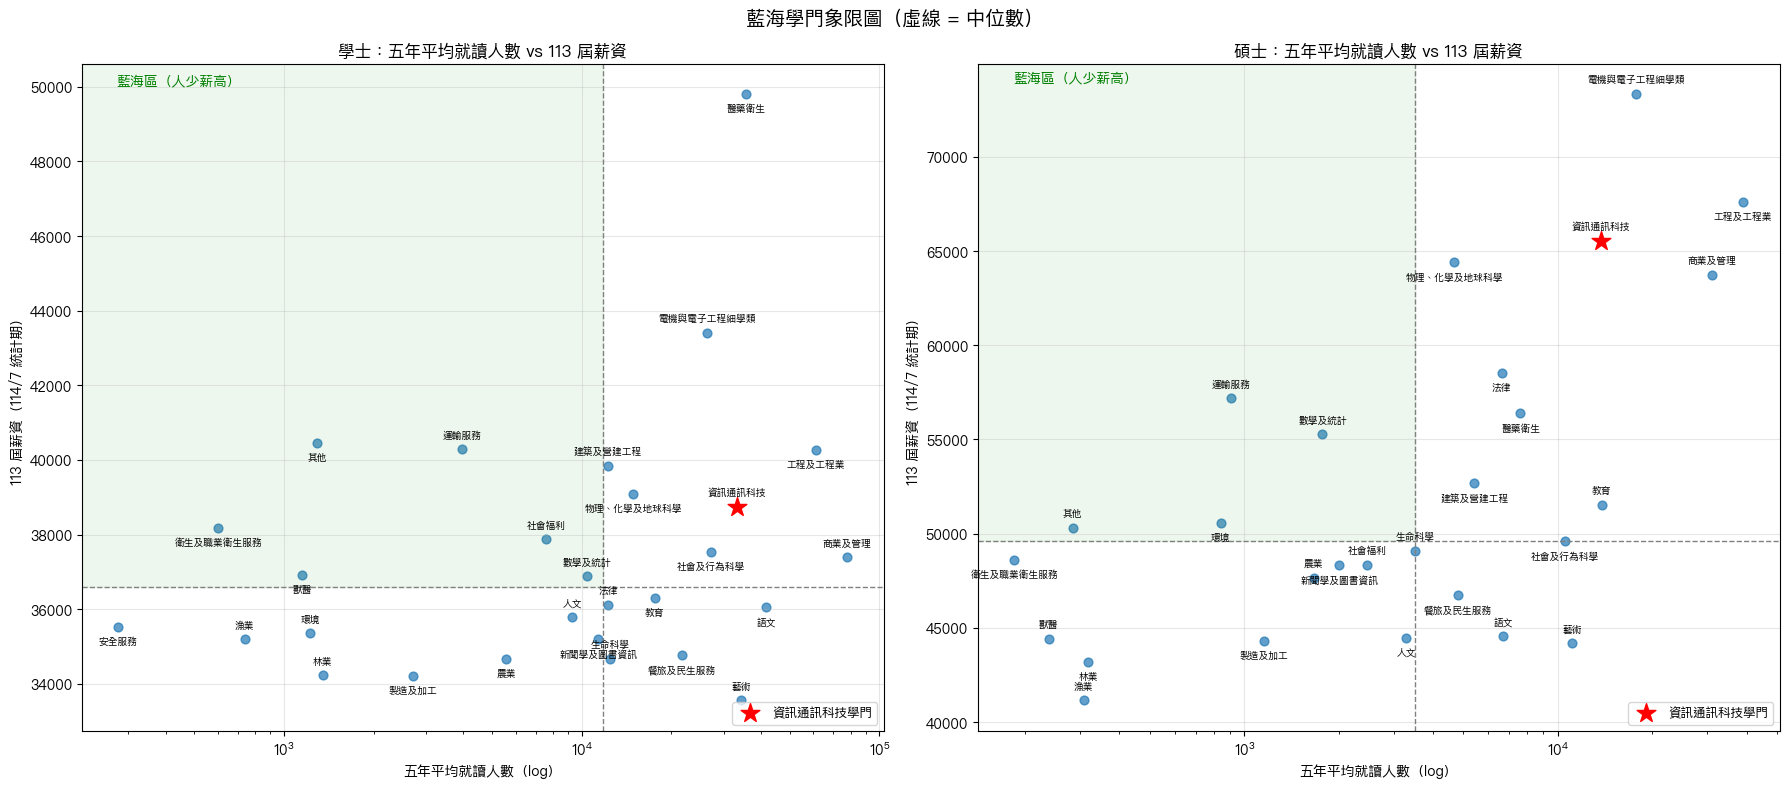

In [27]:
def plot_blue_ocean(df):
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    for ax, degree in zip(axes, ["學士", "碩士"]):
        g = df[df["學位"] == degree]

        med_x = g["五年平均人數"].median()
        med_y = g["薪資_113屆"].median()

        others = g[g["學門"] != TARGET_FIELD]
        target = g[g["學門"] == TARGET_FIELD]

        ax.scatter(
            others["五年平均人數"], others["薪資_113屆"],
            alpha=0.7, s=40, color="tab:blue"
        )
        ax.scatter(
            target["五年平均人數"], target["薪資_113屆"],
            color="red", s=200, marker="*", zorder=3,
            label="資訊通訊科技學門"
        )

        ax.set_xscale("log")

        # 以中位數切象限，左上 = 藍海區（人少薪高）
        xlim, ylim = ax.get_xlim(), ax.get_ylim()
        ax.axvline(med_x, color="gray", linewidth=1, linestyle="--")
        ax.axhline(med_y, color="gray", linewidth=1, linestyle="--")
        ax.fill_between(
            [xlim[0], med_x], med_y, ylim[1],
            color="tab:green", alpha=0.08
        )
        ax.text(
            xlim[0] * 1.3, ylim[1] * 0.995, "藍海區（人少薪高）",
            fontsize=10, color="green", va="top"
        )
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)

        # 全部學門都標名稱，依薪資排序交錯放上下，減少重疊
        for i, (_, r) in enumerate(
            g.sort_values("薪資_113屆").iterrows()
        ):
            above = i % 2 == 0
            ax.annotate(
                r["學門"].replace("學門", ""),
                (r["五年平均人數"], r["薪資_113屆"]),
                textcoords="offset points",
                xytext=(0, 7 if above else -7),
                ha="center",
                va="bottom" if above else "top",
                fontsize=7
            )

        ax.set_title(f"{degree}：五年平均就讀人數 vs 113 屆薪資")
        ax.set_xlabel("五年平均就讀人數（log）")
        ax.set_ylabel("113 屆薪資（114/7 統計期）")
        ax.legend(loc="lower right", fontsize=9)
        ax.grid(True, alpha=0.3)

    fig.suptitle("藍海學門象限圖（虛線 = 中位數）", fontsize=14)
    fig.tight_layout()
    plt.show()

plot_blue_ocean(blue_ocean)

# 延伸分析：雙漲學門（薪資↑ 且 就讀人數↑）

找出「薪資在漲、就讀人數也在漲」的學門。

兩個趨勢的定義：

- **人數趨勢**：109～113 年就讀人數，同時看頭尾變化%（113 vs 109）與五年線性斜率（避免只看頭尾被單年波動誤導），以斜率判斷方向
- **薪資趨勢**：固定年資比較——「畢業滿一年（次年 7 月統計期）」薪資，113 屆 vs 111 屆的變化%。
  受資料期間限制（薪資統計從 112 年 1 月開始），只能比這兩屆

**扣除基本工資成長**：

兩個薪資觀測時點是 112 年 7 月（111 屆滿一年）與 114 年 7 月（113 屆滿一年），
對應的月薪制基本工資為 112 年 26,400 元、114 年 28,590 元，漲幅 **+8.30%**。
名目薪資漲幅低於這個基準的，等於只是被基本工資墊高，不算真漲。

- **實質薪資變化%** =（113 屆薪資 ÷ 111 屆薪資）÷（28,590 ÷ 26,400）− 1
- 雙漲與隱藏版的判斷都改用實質薪資變化

扣掉之後，學士只剩 12/27、碩士只剩 8/26 個學門實質為正——
「薪資普漲」的表象大多是基本工資墊出來的。

In [28]:
# 人數：109～113 逐年人數的頭尾變化與五年線性斜率
years = [109, 110, 111, 112, 113]

en_pivot = enroll_yearly.pivot_table(
    index=["學位", "學門"], columns="年份", values="學生數"
)
en_pivot["人數變化%"] = (en_pivot[113] / en_pivot[109] - 1) * 100
en_pivot["人數斜率"] = en_pivot[years].apply(
    lambda r: np.polyfit(years, r.values.astype(float), 1)[0]
    if r.notna().all() else np.nan,
    axis=1
)

# 薪資：固定年資（畢業滿一年）各屆薪資，113 屆 vs 111 屆
one_year_salary = salary_periods[
    (salary_periods["統計期_year"] == salary_periods["畢業年份"] + 1)
    & (salary_periods["統計期_month"] == 7)
]
sal_pivot = one_year_salary.pivot_table(
    index=["學位", "學門"], columns="畢業年份", values="薪資"
)

# 月薪制基本工資：112年（111屆滿一年的觀測時點）與 114年（113屆）
MIN_WAGE_112 = 26400
MIN_WAGE_114 = 28590
min_wage_growth = MIN_WAGE_114 / MIN_WAGE_112   # +8.30%

sal_pivot["名目薪資變化%"] = (sal_pivot[113] / sal_pivot[111] - 1) * 100
sal_pivot["實質薪資變化%"] = (
    (sal_pivot[113] / sal_pivot[111]) / min_wage_growth - 1
) * 100

trend_change = (
    en_pivot[["人數變化%", "人數斜率"]]
    .join(sal_pivot[[111, 113, "名目薪資變化%", "實質薪資變化%"]])
    .reset_index()
    .rename(columns={111: "滿一年薪資_111屆", 113: "滿一年薪資_113屆"})
    .dropna(subset=["實質薪資變化%"])
)

print(f"基本工資成長基準：{MIN_WAGE_112:,} → {MIN_WAGE_114:,}（+{(min_wage_growth - 1) * 100:.2f}%）")
print()

show_cols = [
    "學門", "人數變化%",
    "滿一年薪資_111屆", "滿一年薪資_113屆",
    "名目薪資變化%", "實質薪資變化%"
]

for degree in ["學士", "碩士"]:
    g = trend_change[trend_change["學位"] == degree]

    real_up = (g["實質薪資變化%"] > 0).sum()
    print(f"{degree}：實質薪資為正的學門 {real_up}/{len(g)} 個")

    double_up = (
        g[(g["人數斜率"] > 0) & (g["實質薪資變化%"] > 0)]
        .sort_values("實質薪資變化%", ascending=False)
    )
    print(f"===== {degree}：雙漲學門（人數↑ 且 實質薪資↑，共 {len(double_up)} 個）=====")
    print(double_up[show_cols].round(1).to_string(index=False))
    print()

print("===== 隱藏版機會：實質薪資↑ 但人數↓（供給縮、價格漲）=====")
hidden = (
    trend_change[
        (trend_change["人數斜率"] < 0)
        & (trend_change["實質薪資變化%"] > 0)
    ]
    .sort_values("實質薪資變化%", ascending=False)
)
print(hidden[["學位"] + show_cols].round(1).to_string(index=False))

基本工資成長基準：26,400 → 28,590（+8.30%）

學士：實質薪資為正的學門 12/27 個
===== 學士：雙漲學門（人數↑ 且 實質薪資↑，共 1 個）=====
    學門  人數變化%  滿一年薪資_111屆  滿一年薪資_113屆  名目薪資變化%  實質薪資變化%
醫藥衛生學門    4.7     44895.0     49808.0     10.9      2.4

碩士：實質薪資為正的學門 8/26 個
===== 碩士：雙漲學門（人數↑ 且 實質薪資↑，共 4 個）=====
          學門  人數變化%  滿一年薪資_111屆  滿一年薪資_113屆  名目薪資變化%  實質薪資變化%
        教育學門    3.6     46711.0     51516.0     10.3      1.8
        人文學門    0.6     40509.0     44461.0      9.8      1.3
物理、化學及地球科學學門    3.9     58964.0     64397.0      9.2      0.8
      醫藥衛生學門    3.0     52069.0     56390.0      8.3      0.0

===== 隱藏版機會：實質薪資↑ 但人數↓（供給縮、價格漲）=====
學位         學門  人數變化%  滿一年薪資_111屆  滿一年薪資_113屆  名目薪資變化%  實質薪資變化%
學士  建築及營建工程學門   -8.5     35458.0     39838.0     12.4      3.7
碩士  餐旅及民生服務學門  -16.2     42073.0     46742.0     11.1      2.6
學士       漁業學門   -1.9     31885.0     35199.0     10.4      1.9
學士       環境學門   -0.7     32070.0     35352.0     10.2      1.8
學士  餐旅及民生服務學門  -28.8     31632.0     34772.0      9.9      1.5
學士 新聞學及圖書資

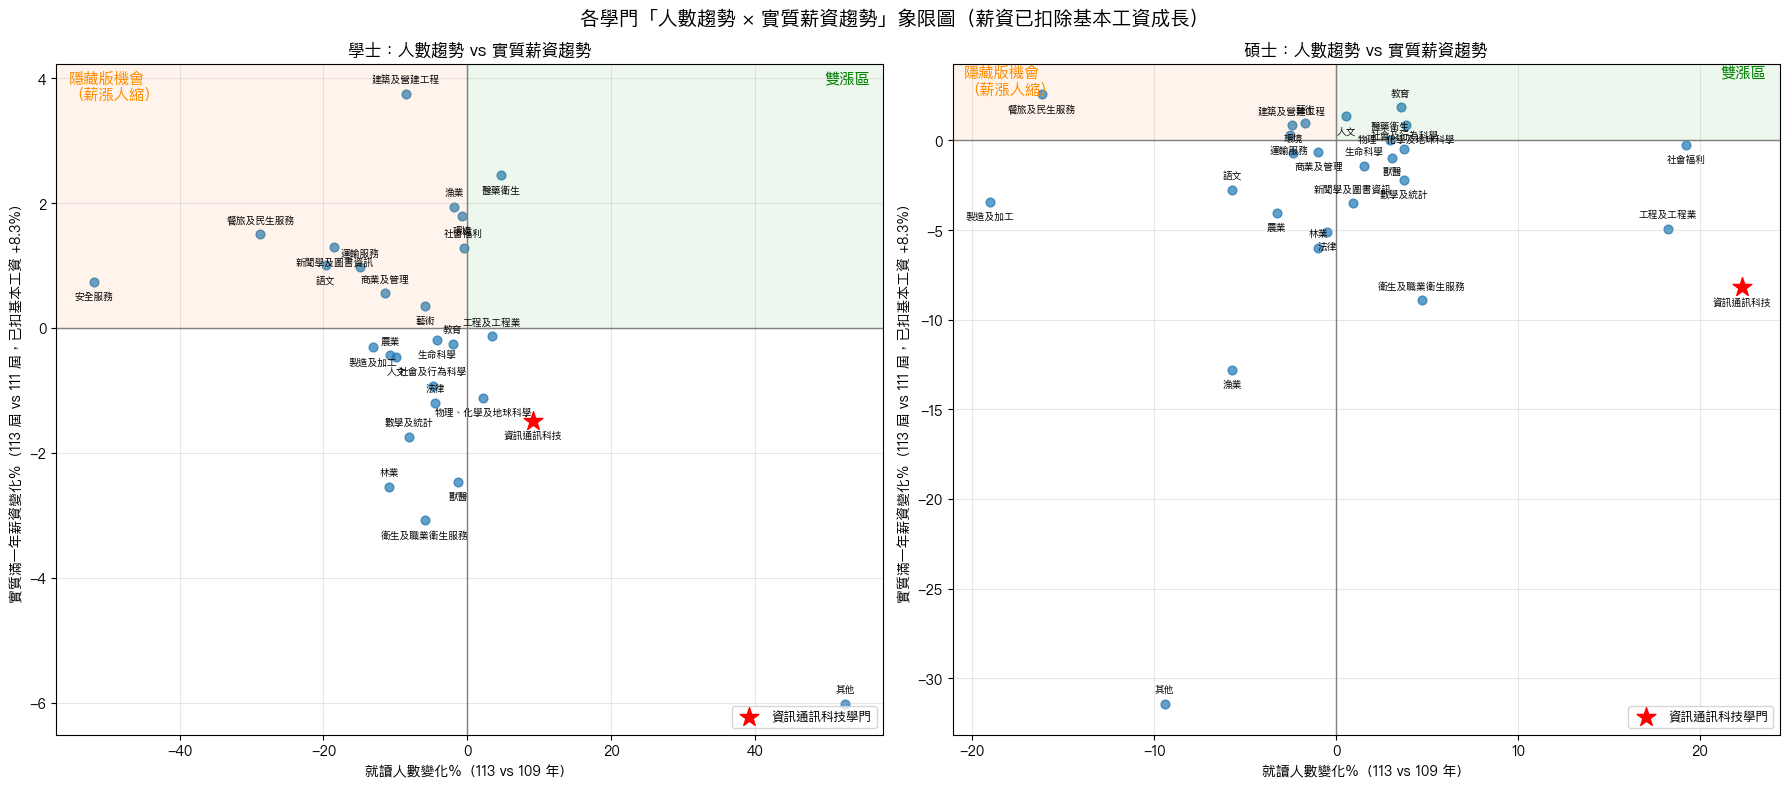

In [29]:
def plot_trend_quadrant(df):
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    for ax, degree in zip(axes, ["學士", "碩士"]):
        g = df[df["學位"] == degree]

        others = g[g["學門"] != TARGET_FIELD]
        target = g[g["學門"] == TARGET_FIELD]

        ax.scatter(
            others["人數變化%"], others["實質薪資變化%"],
            alpha=0.7, s=40, color="tab:blue"
        )
        ax.scatter(
            target["人數變化%"], target["實質薪資變化%"],
            color="red", s=200, marker="*", zorder=3,
            label="資訊通訊科技學門"
        )

        ax.axvline(0, color="gray", linewidth=1)
        ax.axhline(0, color="gray", linewidth=1)

        xlim, ylim = ax.get_xlim(), ax.get_ylim()
        # 右上：雙漲區；左上：隱藏版機會（實質薪資漲、人數縮）
        ax.fill_between([0, xlim[1]], 0, ylim[1], color="tab:green", alpha=0.08)
        ax.fill_between([xlim[0], 0], 0, ylim[1], color="tab:orange", alpha=0.08)
        ax.text(
            xlim[1] * 0.97, ylim[1] * 0.97, "雙漲區",
            fontsize=11, color="green", ha="right", va="top"
        )
        ax.text(
            xlim[0] * 0.97, ylim[1] * 0.97, "隱藏版機會\n（薪漲人縮）",
            fontsize=11, color="darkorange", ha="left", va="top"
        )
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)

        # 全部學門都標名稱，依薪資變化排序交錯放上下，減少重疊
        for i, (_, r) in enumerate(
            g.sort_values("實質薪資變化%").iterrows()
        ):
            above = i % 2 == 0
            ax.annotate(
                r["學門"].replace("學門", ""),
                (r["人數變化%"], r["實質薪資變化%"]),
                textcoords="offset points",
                xytext=(0, 7 if above else -7),
                ha="center",
                va="bottom" if above else "top",
                fontsize=7
            )

        ax.set_title(f"{degree}：人數趨勢 vs 實質薪資趨勢")
        ax.set_xlabel("就讀人數變化%（113 vs 109 年）")
        ax.set_ylabel("實質滿一年薪資變化%（113 屆 vs 111 屆，已扣基本工資 +8.3%）")
        ax.legend(loc="lower right", fontsize=9)
        ax.grid(True, alpha=0.3)

    fig.suptitle(
        "各學門「人數趨勢 × 實質薪資趨勢」象限圖（薪資已扣除基本工資成長）",
        fontsize=14
    )
    fig.tight_layout()
    plt.show()

plot_trend_quadrant(trend_change)